# 🛒 E-Commerce Intelligence Platform
## Phase 4 — Customer Segmentation (RFM Model)
**Goal:** Segment customers into meaningful groups based on behavior  
**Model:** RFM — Recency, Frequency, Monetary  
**Analyst:** Shivansh Pandey



In [1]:
# ============================================================
# CELL 1 — IMPORTS & UPLOAD
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

from google.colab import files
uploaded = files.upload()

print("✅ Libraries imported & files uploaded")

Saving master_dataset.csv to master_dataset.csv
✅ Libraries imported & files uploaded


In [2]:
# ============================================================
# CELL 2 — LOAD & PREPARE DATA
# ============================================================

master = pd.read_csv('master_dataset.csv')

# Convert date column
master['order_purchase_timestamp'] = pd.to_datetime(master['order_purchase_timestamp'])

# Reference date — day after last order in dataset
# This is standard RFM practice
reference_date = master['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

print(f"✅ Data loaded: {master.shape}")
print(f"📅 Reference date for Recency: {reference_date.date()}")
print(f"👥 Unique customers: {master['customer_unique_id'].nunique():,}")

✅ Data loaded: (110189, 29)
📅 Reference date for Recency: 2018-08-30
👥 Unique customers: 93,350


In [3]:
# ============================================================
# CELL 3 — BUILD RFM TABLE
# R = Recency   → How recently did they buy?
# F = Frequency → How often do they buy?
# M = Monetary  → How much do they spend?
# ============================================================

rfm = master.groupby('customer_unique_id').agg(
    recency   = ('order_purchase_timestamp',
                  lambda x: (reference_date - x.max()).days),
    frequency = ('order_id', 'nunique'),
    monetary  = ('total_payment', 'sum')
).reset_index()

# Round monetary
rfm['monetary'] = rfm['monetary'].round(2)

print("✅ RFM Table built!")
print(f"\n📊 RFM Summary Statistics:")
print(rfm[['recency', 'frequency', 'monetary']].describe().round(2))

✅ RFM Table built!

📊 RFM Summary Statistics:
       recency  frequency  monetary
count 93350.00   93350.00  93350.00
mean    237.95       1.03    211.83
std     152.59       0.21    642.19
min       1.00       1.00      0.00
25%     114.00       1.00     63.74
50%     219.00       1.00    112.95
75%     346.00       1.00    201.74
max     714.00      15.00 109312.64


In [4]:
# ============================================================
# CELL 4 — ASSIGN RFM SCORES (1-5)
# 5 = Best, 1 = Worst
# Recency: lower days = better score
# Frequency & Monetary: higher = better score
# ============================================================

# Score Recency (lower recency = more recent = better = score 5)
rfm['r_score'] = pd.qcut(rfm['recency'],
                          q=5,
                          labels=[5, 4, 3, 2, 1],
                          duplicates='drop').astype(int)

# Score Frequency
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'),
                          q=5,
                          labels=[1, 2, 3, 4, 5]).astype(int)

# Score Monetary
rfm['m_score'] = pd.qcut(rfm['monetary'].rank(method='first'),
                          q=5,
                          labels=[1, 2, 3, 4, 5]).astype(int)

# Combined RFM Score
rfm['rfm_score'] = rfm['r_score'].astype(str) + \
                   rfm['f_score'].astype(str) + \
                   rfm['m_score'].astype(str)

# Total score (sum)
rfm['total_score'] = rfm['r_score'] + rfm['f_score'] + rfm['m_score']

print("✅ RFM Scores assigned!")
print(rfm[['customer_unique_id', 'recency', 'frequency',
           'monetary', 'r_score', 'f_score', 'm_score',
           'rfm_score', 'total_score']].head(10))

✅ RFM Scores assigned!
                 customer_unique_id  recency  frequency  monetary  r_score  \
0  0000366f3b9a7992bf8c76cfdf3221e2      112          1    141.90        4   
1  0000b849f77a49e4a4ce2b2a4ca5be3f      115          1     27.19        4   
2  0000f46a3911fa3c0805444483337064      537          1     86.22        1   
3  0000f6ccb0745a6a4b88665a16c9f078      321          1     43.62        2   
4  0004aac84e0df4da2b147fca70cf8255      288          1    196.89        2   
5  0004bd2a26a76fe21f786e4fbd80607f      146          1    166.98        4   
6  00050ab1314c0e55a6ca13cf7181fecf      132          1     35.38        4   
7  00053a61a98854899e70ed204dd4bafe      183          1    838.36        3   
8  0005e1862207bf6ccc02e4228effd9a0      543          1    150.12        1   
9  0005ef4cd20d2893f0d9fbd94d3c0d97      170          1    129.76        4   

   f_score  m_score rfm_score  total_score  
0        1        4       414            9  
1        1        1       41

In [5]:
# ============================================================
# CELL 5 — ASSIGN CUSTOMER SEGMENTS
# Based on RFM scores, group customers into segments
# ============================================================

def assign_segment(row):
    r = row['r_score']
    f = row['f_score']
    m = row['m_score']
    score = row['total_score']

    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r >= 3 and f >= 2 and m >= 2:
        return 'Potential Loyalists'
    elif r == 3 and f <= 2:
        return 'Promising'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'
    elif r <= 2 and f >= 2:
        return 'Cannot Lose Them'
    elif r == 2 and f <= 2:
        return 'Hibernating'
    else:
        return 'Lost'

rfm['segment'] = rfm.apply(assign_segment, axis=1)

# Segment summary
segment_summary = rfm.groupby('segment').agg(
    customer_count = ('customer_unique_id', 'count'),
    avg_recency    = ('recency', 'mean'),
    avg_frequency  = ('frequency', 'mean'),
    avg_monetary   = ('monetary', 'mean'),
    total_revenue  = ('monetary', 'sum')
).round(2).reset_index()

segment_summary = segment_summary.sort_values('total_revenue', ascending=False)

print("✅ Segments assigned!")
print(f"\n{'='*70}")
print(f"{'Segment':<22} {'Customers':>10} {'Avg Recency':>12} {'Avg Freq':>10} {'Avg Spend':>10}")
print(f"{'='*70}")
for _, row in segment_summary.iterrows():
    print(f"{row['segment']:<22} {int(row['customer_count']):>10,} {row['avg_recency']:>12.0f} {row['avg_frequency']:>10.1f} {row['avg_monetary']:>10.2f}")

✅ Segments assigned!

Segment                 Customers  Avg Recency   Avg Freq  Avg Spend
At Risk                    13,226          394        1.1     318.14
Loyal Customers            14,213          153        1.1     267.30
New Customers              14,980           91        1.0     204.36
Champions                   6,459           91        1.2     442.11
Cannot Lose Them           16,506          395        1.0     126.71
Potential Loyalists         9,294          161        1.0     120.24
Lost                       10,522          258        1.0      97.80
Hibernating                 3,655          316        1.0     238.43
Promising                   4,495          220        1.0     164.91


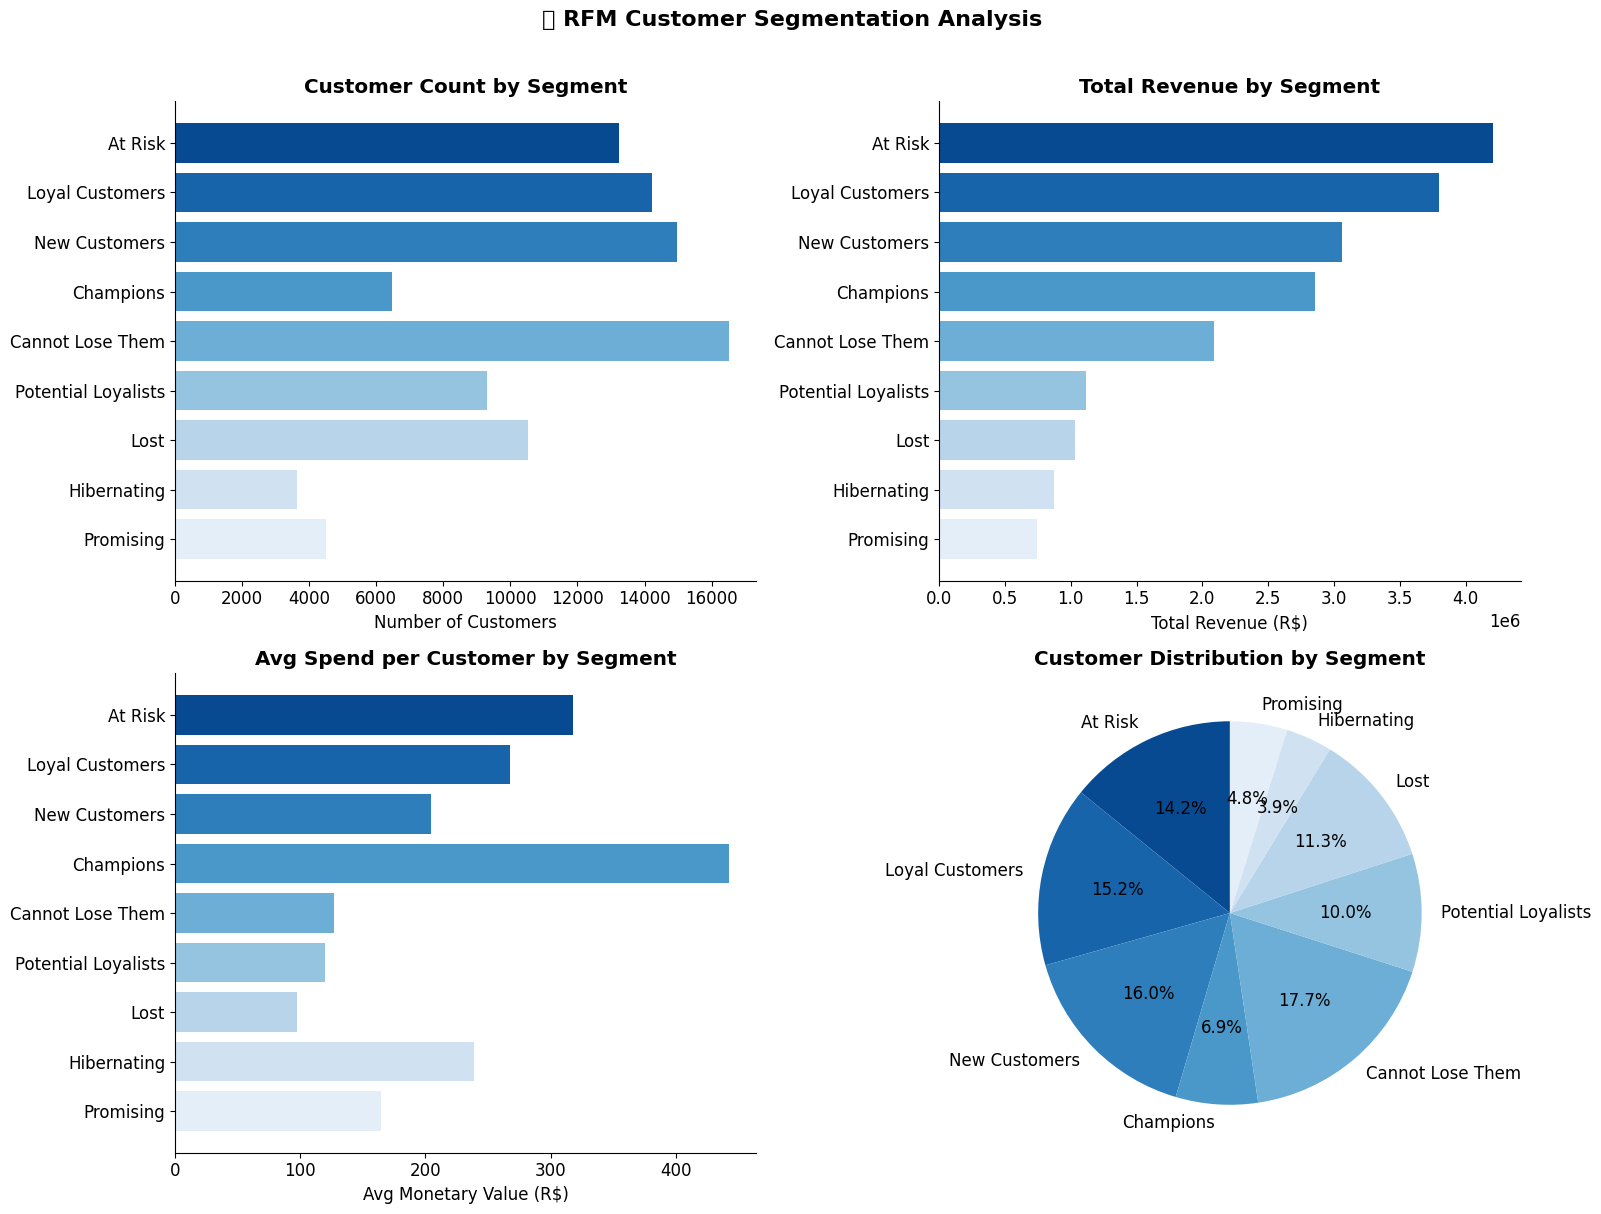

In [6]:
# ============================================================
# CELL 6 — VISUALIZE CUSTOMER SEGMENTS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Color palette
colors = sns.color_palette('Blues_r', len(segment_summary))

# Plot 1 — Customer Count per Segment
axes[0,0].barh(segment_summary['segment'],
               segment_summary['customer_count'], color=colors)
axes[0,0].set_title('Customer Count by Segment', fontweight='bold')
axes[0,0].set_xlabel('Number of Customers')
axes[0,0].invert_yaxis()

# Plot 2 — Total Revenue per Segment
axes[0,1].barh(segment_summary['segment'],
               segment_summary['total_revenue'], color=colors)
axes[0,1].set_title('Total Revenue by Segment', fontweight='bold')
axes[0,1].set_xlabel('Total Revenue (R$)')
axes[0,1].invert_yaxis()

# Plot 3 — Avg Monetary per Segment
axes[1,0].barh(segment_summary['segment'],
               segment_summary['avg_monetary'], color=colors)
axes[1,0].set_title('Avg Spend per Customer by Segment', fontweight='bold')
axes[1,0].set_xlabel('Avg Monetary Value (R$)')
axes[1,0].invert_yaxis()

# Plot 4 — Pie chart of customer distribution
axes[1,1].pie(segment_summary['customer_count'],
              labels=segment_summary['segment'],
              autopct='%1.1f%%',
              colors=sns.color_palette('Blues_r', len(segment_summary)),
              startangle=90)
axes[1,1].set_title('Customer Distribution by Segment', fontweight='bold')

plt.suptitle('👥 RFM Customer Segmentation Analysis',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

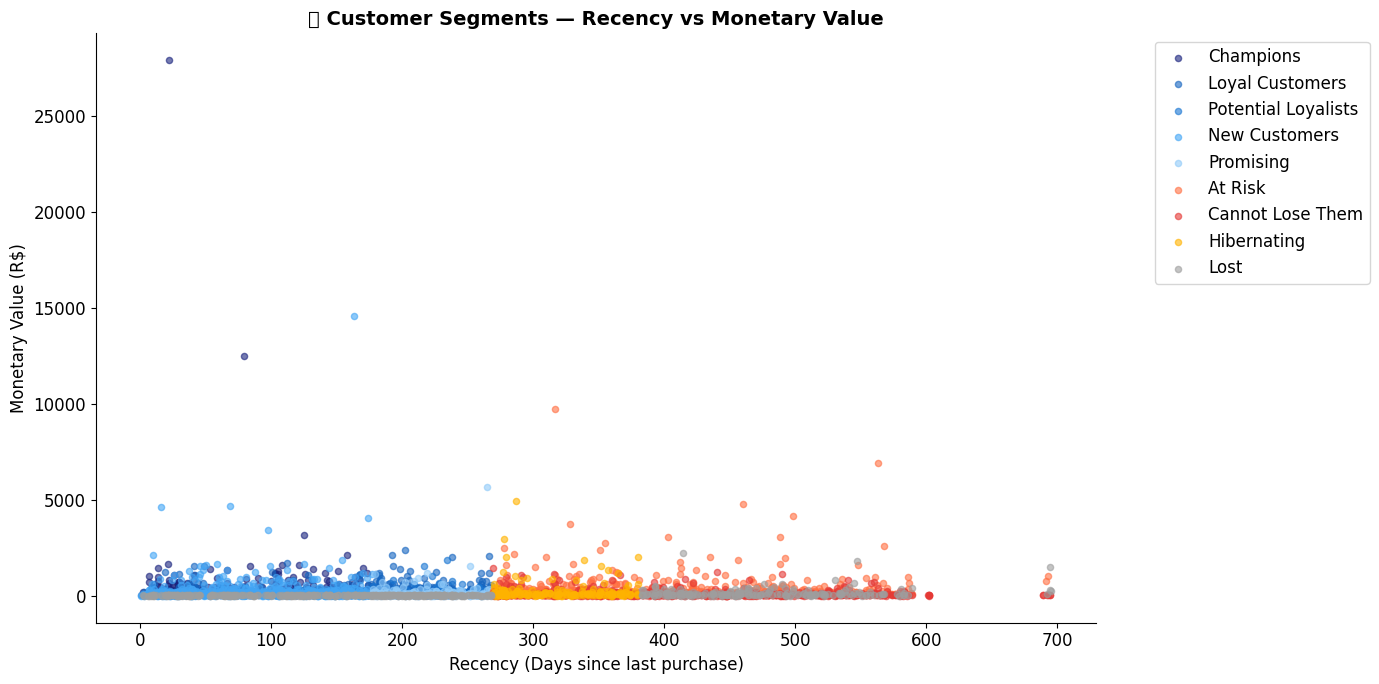

In [7]:
# ============================================================
# CELL 7 — RFM SCATTER PLOT
# Visualize Recency vs Monetary colored by Segment
# ============================================================

# Sample for performance
rfm_sample = rfm.sample(min(5000, len(rfm)), random_state=42)

segment_colors = {
    'Champions'          : '#1a237e',
    'Loyal Customers'    : '#1565c0',
    'Potential Loyalists': '#1976d2',
    'New Customers'      : '#42a5f5',
    'Promising'          : '#90caf9',
    'At Risk'            : '#ff7043',
    'Cannot Lose Them'   : '#e53935',
    'Hibernating'        : '#ffb300',
    'Lost'               : '#9e9e9e'
}

plt.figure(figsize=(14, 7))
for segment, color in segment_colors.items():
    mask = rfm_sample['segment'] == segment
    if mask.sum() > 0:
        plt.scatter(rfm_sample[mask]['recency'],
                    rfm_sample[mask]['monetary'],
                    c=color, label=segment,
                    alpha=0.6, s=20)

plt.xlabel('Recency (Days since last purchase)', fontsize=12)
plt.ylabel('Monetary Value (R$)', fontsize=12)
plt.title('🎯 Customer Segments — Recency vs Monetary Value',
          fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [8]:
# ============================================================
# CELL 8 — BUSINESS RECOMMENDATIONS PER SEGMENT
# This is what separates analysts from data scientists
# ============================================================

recommendations = {
    'Champions'          : 'Reward them. Make them brand ambassadors. Offer loyalty perks.',
    'Loyal Customers'    : 'Upsell higher value products. Ask for reviews.',
    'Potential Loyalists': 'Offer membership/loyalty programs to convert them.',
    'New Customers'      : 'Provide onboarding support & first purchase discounts.',
    'Promising'          : 'Build brand awareness, offer free trials.',
    'At Risk'            : 'Send personalised reactivation emails. Offer discounts.',
    'Cannot Lose Them'   : 'Win them back via renewals or newer products.',
    'Hibernating'        : 'Offer relevant products & special discounts.',
    'Lost'               : 'Revive interest with reach-out campaigns or ignore.'
}

print("=" * 70)
print("        💡 BUSINESS RECOMMENDATIONS BY SEGMENT")
print("=" * 70)
for segment, rec in recommendations.items():
    count = rfm[rfm['segment'] == segment].shape[0]
    print(f"\n🎯 {segment} ({count:,} customers)")
    print(f"   → {rec}")

        💡 BUSINESS RECOMMENDATIONS BY SEGMENT

🎯 Champions (6,459 customers)
   → Reward them. Make them brand ambassadors. Offer loyalty perks.

🎯 Loyal Customers (14,213 customers)
   → Upsell higher value products. Ask for reviews.

🎯 Potential Loyalists (9,294 customers)
   → Offer membership/loyalty programs to convert them.

🎯 New Customers (14,980 customers)
   → Provide onboarding support & first purchase discounts.

🎯 Promising (4,495 customers)
   → Build brand awareness, offer free trials.

🎯 At Risk (13,226 customers)
   → Send personalised reactivation emails. Offer discounts.

🎯 Cannot Lose Them (16,506 customers)
   → Win them back via renewals or newer products.

🎯 Hibernating (3,655 customers)
   → Offer relevant products & special discounts.

🎯 Lost (10,522 customers)
   → Revive interest with reach-out campaigns or ignore.


In [9]:
# ============================================================
# CELL 9 — SAVE RFM RESULTS
# ============================================================

rfm.to_csv('rfm_segments.csv', index=False)
segment_summary.to_csv('rfm_summary.csv', index=False)

files.download('rfm_segments.csv')
files.download('rfm_summary.csv')

print("=" * 55)
print("        ✅ PHASE 4 SUMMARY")
print("=" * 55)
print(f"  Total Customers Segmented : {len(rfm):,}")
print(f"  Total Segments            : {rfm['segment'].nunique()}")
print(f"  Champions                 : {(rfm['segment']=='Champions').sum():,}")
print(f"  At Risk                   : {(rfm['segment']=='At Risk').sum():,}")
print(f"  Lost                      : {(rfm['segment']=='Lost').sum():,}")
print("=" * 55)
print("✅ Phase 4 Complete — Ready for Churn Analysis!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

        ✅ PHASE 4 SUMMARY
  Total Customers Segmented : 93,350
  Total Segments            : 9
  Champions                 : 6,459
  At Risk                   : 13,226
  Lost                      : 10,522
✅ Phase 4 Complete — Ready for Churn Analysis!
